## **Conjunto de datos de clasificación de imágenes pequeñas CIFAR10**

### **Efrain Alvarez**

Se sabe que el conjunto de datos CIFAR-10 contiene un pequeño porcentaje de muestras mal etiquetadas, lo cual es inherente al conjunto de datos original. Este ruido en las etiquetas puede afectar el entrenamiento y la evaluación. Para obtener más detalles, consulte las discusiones en la literatura de investigación sobre la calidad de las etiquetas de CIFAR-10.

## Importaciones

Todas las librerías necesarias para el proyecto completo.
Se importan al inicio para tener una visión clara de las dependencias.

In [1]:
# ============================================================
# IMPORTACIONES
# ============================================================

# --- 1. Sistema y utilidades ---
import os
import random
import warnings

# --- 2. Numéricas ---
import numpy as np

# --- 3. Visualización ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# --- 4. Deep Learning — TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# --- 5. Métricas de evaluación ---
from sklearn.metrics import classification_report, confusion_matrix

## Carga del Dataset CIFAR-10

In [2]:
# ============================================================
# CARGA DEL DATASET
# ============================================================

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print(f"X_train : {X_train.shape}  dtype: {X_train.dtype}")
print(f"y_train : {y_train.shape}  dtype: {y_train.dtype}")
print(f"X_test  : {X_test.shape}   dtype: {X_test.dtype}")
print(f"y_test  : {y_test.shape}   dtype: {y_test.dtype}")
print(f"Rango de pixeles : [{X_train.min()} - {X_train.max()}]")
print(f"Total imagenes   : {len(X_train) + len(X_test):,}")

X_train : (50000, 32, 32, 3)  dtype: uint8
y_train : (50000, 1)  dtype: uint8
X_test  : (10000, 32, 32, 3)   dtype: uint8
y_test  : (10000, 1)   dtype: uint8
Rango de pixeles : [0 - 255]
Total imagenes   : 60,000


## Visualización de las primeras 30 imágenes

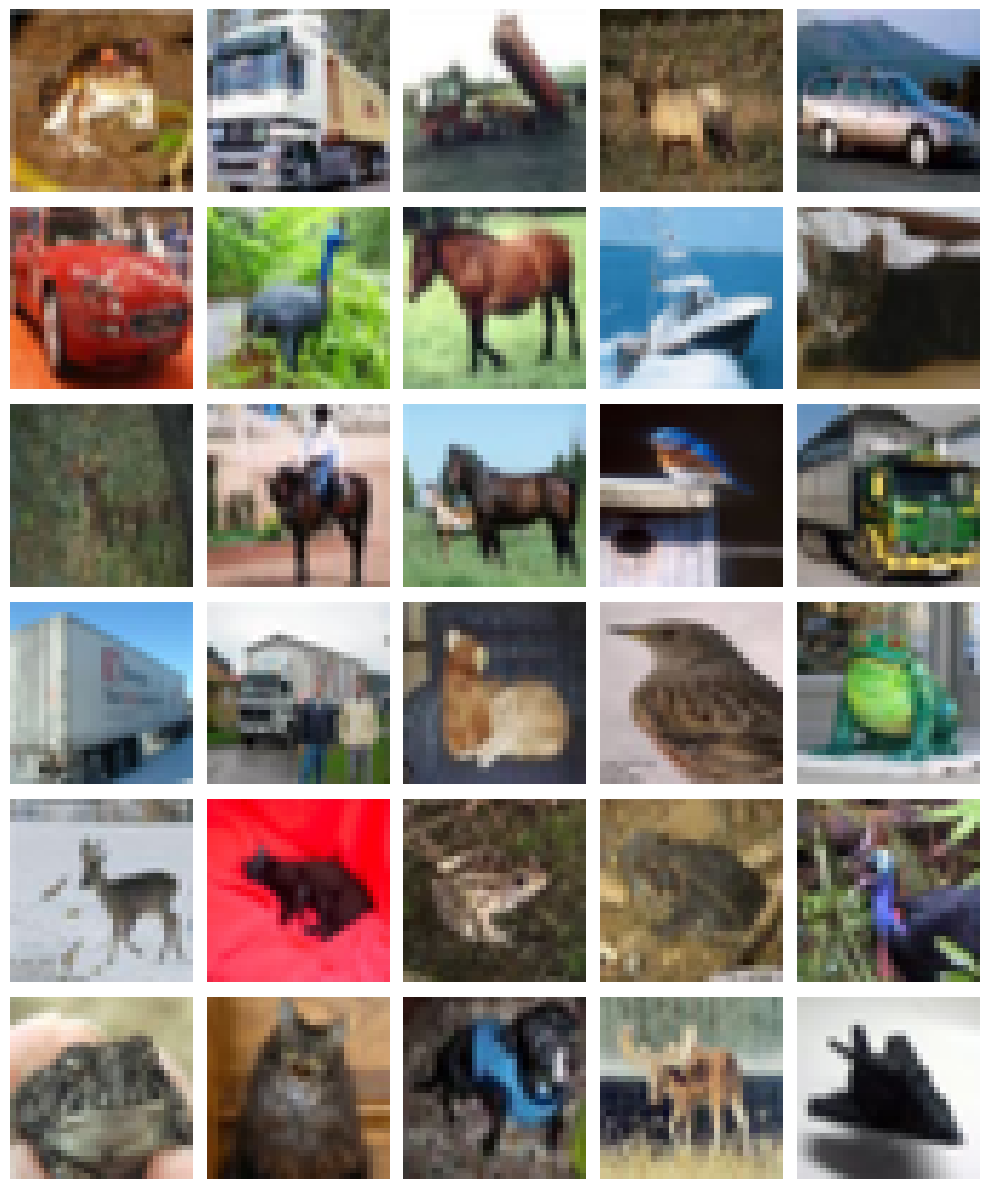

In [3]:
# Cuadrícula de 6 filas x 5 columnas para mostrar 30 imágenes
fig, axes = plt.subplots(6, 5, figsize=(10, 12))

# Recorrer cada celda de la cuadrícula
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])                          # Mostrar la imagen en color RGB
    ax.axis('off')                                 # Ocultar ejes

plt.tight_layout()
plt.show()

## Clases únicas en el dataset

In [4]:
# Clases únicas presentes en el conjunto de entrenamiento
print(np.unique(y_train))

# Cantidad de clases únicas
print(f"Numero de clases unicas: {len(np.unique(y_train))}")

[0 1 2 3 4 5 6 7 8 9]
Numero de clases unicas: 10


## Asignación de nombres de clases

In [5]:
# Nombres de las 10 clases en el orden que usa CIFAR-10 (índice 0-9)
CLASS_NAMES = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

## Normalización de imágenes

Se dividen los valores de píxeles entre 255 para llevarlos al rango [0, 1].
Esto mejora la convergencia durante el entrenamiento.

In [6]:
# Convertir a float32 y normalizar al rango [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Verificar el nuevo rango de valores
print(f"Rango X_train: [{X_train.min()} - {X_train.max()}]")
print(f"Rango X_test : [{X_test.min()} - {X_test.max()}]")

Rango X_train: [0.0 - 1.0]
Rango X_test : [0.0 - 1.0]


## Construccion del modelo CNN

Red convolucional con tres bloques de convolucion seguidos de capas densas.
Adecuada para imagenes pequenas de 32x32 como las de CIFAR-10.
Se agrega data augmentation para aumentar la variedad de imagenes durante el entrenamiento
y se aumenta el Dropout para reducir el sobreajuste.

In [7]:
model = models.Sequential([

    # Data augmentation
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # Primer bloque convolucional
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Segundo bloque convolucional
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Tercer bloque convolucional
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Definir explicitamente la entrada como imagenes de 32x32 con 3 canales RGB
model.build(input_shape=(None, 32, 32, 3))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,242 (9.95 MB)

 Trainable params: 2,604,810 (9.94 MB)

 Non-trainable params: 2,432 (9.50 KB)

## Compilación del modelo

Se usa `sparse_categorical_crossentropy` por lo que las etiquetas deben ser enteros, no one-hot encoding.

In [8]:
# Recargar etiquetas originales como enteros (sin one-hot encoding)
(_, y_train), (_, y_test) = cifar10.load_data()

# Compilar el modelo con sparse
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',  # Acepta etiquetas como enteros directamente
    metrics=['accuracy']
)

## Entrenamiento del modelo

Se entrena con early stopping para detener el entrenamiento si el modelo deja de mejorar,
y un callback para guardar el mejor modelo.

In [9]:
# Callback para detener el entrenamiento si val_loss no mejora en 5 epochs
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True  # Restaura los pesos del mejor epoch al finalizar
)

# Callback para guardar el mejor modelo en disco y darle persistencia
model_checkpoint = callbacks.ModelCheckpoint(
    filepath='modelo_cifar10.keras',  # Guarda el modelo completo
    monitor='val_accuracy',           # Guarda el modelo con mejor accuracy de validación
    save_best_only=True               # Solo guarda si mejora
)

# Entrenamiento
history = model.fit(
    X_train, y_train,
    epochs=50,                                        # Maximo de epochs
    batch_size=64,                                    # Tamaño del lote
    validation_split=0.2,                             # 20% de train para validación
    callbacks=[early_stopping, model_checkpoint]      # Callbacks activos
)

# Cargar el mejor modelo guardado por el checkpoint
model = keras.models.load_model('modelo_cifar10.keras')
print("Mejor modelo cargado correctamente")

Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3195 - loss: 2.3214 - val_accuracy: 0.4951 - val_loss: 1.4274
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4064 - loss: 1.8511 - val_accuracy: 0.5204 - val_loss: 1.4270
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.4522 - loss: 1.6435 - val_accuracy: 0.5097 - val_loss: 1.4621
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4893 - loss: 1.5028 - val_accuracy: 0.5975 - val_loss: 1.1776
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - accuracy: 0.5182 - loss: 1.3930 - val_accuracy: 0.5772 - val_loss: 1.2432
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5359 - loss: 1.3170 - val_accuracy: 0.6096 - val_loss: 1.1563
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5656 - loss: 1.2421 - val_accuracy: 0.6334 - val_loss: 1.0617
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.5832 - loss: 1.1856 - 

## Visualización del entrenamiento

Curvas de accuracy y loss para entrenamiento y validación a lo largo de los epochs.

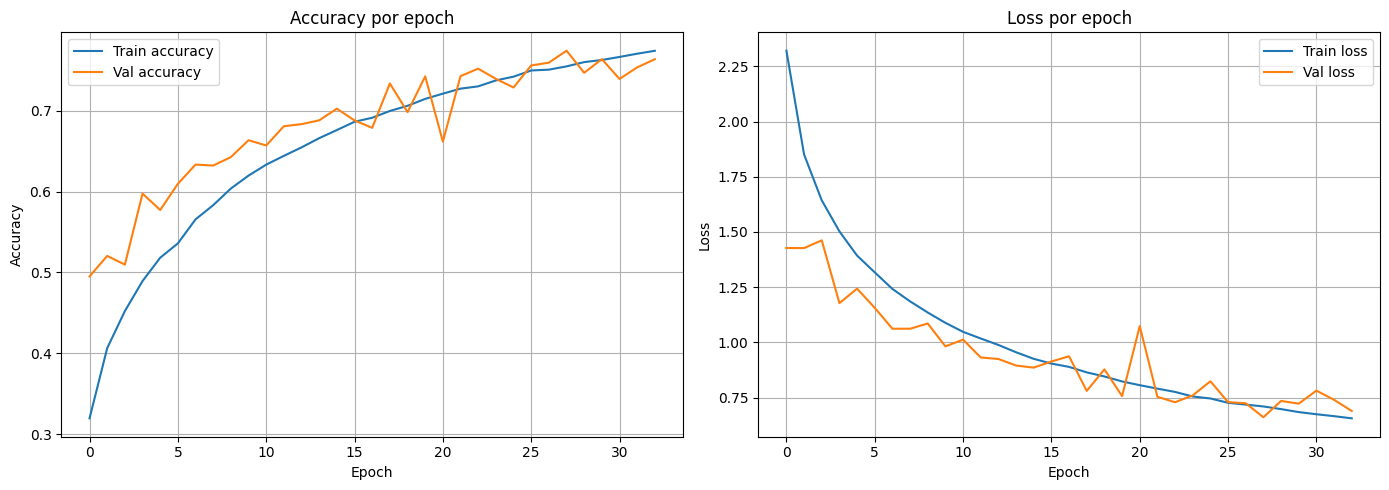

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafica de accuracy
axes[0].plot(history.history['accuracy'],     label='Train accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val accuracy')
axes[0].set_title('Accuracy por epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Grafica de loss
axes[1].plot(history.history['loss'],     label='Train loss')
axes[1].plot(history.history['val_loss'], label='Val loss')
axes[1].set_title('Loss por epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluacion final sobre el conjunto de test

In [11]:
# Evaluar el modelo sobre el conjunto de test
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7644 - loss: 0.6744
Test loss     : 0.6744
Test accuracy : 0.7644
